In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
state_cases = pd.read_csv("us_county_confirmed_cases.csv")
state_deaths = pd.read_csv("us_county_confirmed_deaths.csv")

state_cases = state_cases.drop(columns=['COUNTY', 'NAME', 'POP70', 'HHD70', 'POP80', 'HHD80', 'POP90', 'HHD90',
       'POP00', 'HHD00', 'POP10', 'HHD10', 'countyFIPS', 'County Name', 'State', 'StateFIPS'])
state_deaths = state_deaths.drop(columns=['COUNTY', 'NAME', 'POP70', 'HHD70', 'POP80', 'HHD80', 'POP90', 'HHD90',
       'POP00', 'HHD00','POP10', 'HHD10', 'countyFIPS', 'County Name', 'State', 'StateFIPS'])

In [167]:
case_county = pd.DataFrame(state_cases)
len(case_county)
case_county['2022/9/1']

0       18125.0
1       64672.0
2        6757.0
3        7394.0
4       16597.0
         ...   
3138    12063.0
3139    11526.0
3140     6061.0
3141     2631.0
3142     1790.0
Name: 2022/9/1, Length: 3143, dtype: float64

### how many 0 in that day

In [168]:
for col in list(case_county.columns):
    zero = len(case_county[case_county[col] == 0])
    pct_zero_c = zero/len(case_county)
    
    # need to define drop dates with how many 0
    if pct_zero_c > 0.2:
        print(col)
        case_county.drop(columns= col,inplace = True)

2020/1/22
2020/1/23
2020/1/24
2020/1/25
2020/1/26
2020/1/27
2020/1/28
2020/1/29
2020/1/30
2020/1/31
2020/2/1
2020/2/2
2020/2/3
2020/2/4
2020/2/5
2020/2/6
2020/2/7
2020/2/8
2020/2/9
2020/2/10
2020/2/11
2020/2/12
2020/2/13
2020/2/14
2020/2/15
2020/2/16
2020/2/17
2020/2/18
2020/2/19
2020/2/20
2020/2/21
2020/2/22
2020/2/23
2020/2/24
2020/2/25
2020/2/26
2020/2/27
2020/2/28
2020/2/29
2020/3/1
2020/3/2
2020/3/3
2020/3/4
2020/3/5
2020/3/6
2020/3/7
2020/3/8
2020/3/9
2020/3/10
2020/3/11
2020/3/12
2020/3/13
2020/3/14
2020/3/15
2020/3/16
2020/3/17
2020/3/18
2020/3/19
2020/3/20
2020/3/21
2020/3/22
2020/3/23
2020/3/24
2020/3/25
2020/3/26
2020/3/27
2020/3/28
2020/3/29
2020/3/30
2020/3/31
2020/4/1
2020/4/2
2020/4/3
2020/4/4
2020/4/5
2020/4/6


In [169]:
case_county

,2020/4/7,2020/4/8,2020/4/9,2020/4/10,2020/4/11,2020/4/12,2020/4/13,2020/4/14,2020/4/15,2020/4/16,...,2023/4/8,2023/4/9,2023/4/10,2023/4/11,2023/4/12,2023/4/13,2023/4/14,2023/4/15,2023/4/16,2023/4/17
0,12.0,12.0,17.0,17.0,19.0,19.0,19.0,23.0,25.0,25.0,...,19857.0,19857.0,19857.0,19857.0,19857.0,19873.0,19873.0,19873.0,19873.0,19873.0
1,42.0,49.0,59.0,59.0,66.0,71.0,78.0,87.0,98.0,102.0,...,70248.0,70248.0,70248.0,70248.0,70248.0,70299.0,70299.0,70299.0,70299.0,70299.0
2,3.0,3.0,7.0,9.0,10.0,10.0,10.0,11.0,13.0,14.0,...,7520.0,7520.0,7520.0,7520.0,7520.0,7553.0,7553.0,7553.0,7553.0,7553.0
3,8.0,9.0,11.0,11.0,13.0,16.0,17.0,17.0,19.0,23.0,...,8119.0,8119.0,8119.0,8119.0,8119.0,8122.0,8122.0,8122.0,8122.0,8122.0
4,10.0,10.0,11.0,12.0,12.0,13.0,15.0,16.0,17.0,18.0,...,18800.0,18800.0,18800.0,18800.0,18800.0,18817.0,18817.0,18817.0,18817.0,18817.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3138,6.0,6.0,6.0,7.0,7.0,7.0,9.0,9.0,10.0,10.0,...,12527.0,12527.0,12527.0,12527.0,12527.0,12527.0,12532.0,12532.0,12532.0,12532.0
3139,44.0,45.0,50.0,53.0,53.0,56.0,56.0,57.0,59.0,59.0,...,12156.0,12156.0,12156.0,12156.0,12156.0,12156.0,12161.0,12161.0,12161.0,12161.0
3140,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,...,6426.0,6426.0,6426.0,6426.0,6426.0,6426.0,6427.0,6427.0,6427.0,6427.0
3141,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,...,2702.0,2702.0,2702.0,2702.0,2702.0,2702.0,2702.0,2702.0,2702.0,2702.0


In [4]:
all_cases = pd.DataFrame({'sum': state_cases.sum(axis=0)})
# get daily
all_cases['daily'] = (
    all_cases['sum'].transform(lambda s: s.sub(s.shift().fillna(0)).abs())
)
all_cases = all_cases.tail(-1)

all_deaths = pd.DataFrame({'sum': state_deaths.sum(axis=0)})
# get daily
all_deaths['daily'] = (
    all_deaths['sum'].transform(lambda s: s.sub(s.shift().fillna(0)).abs())
)
all_deaths = all_deaths.tail(-1)

<AxesSubplot: >

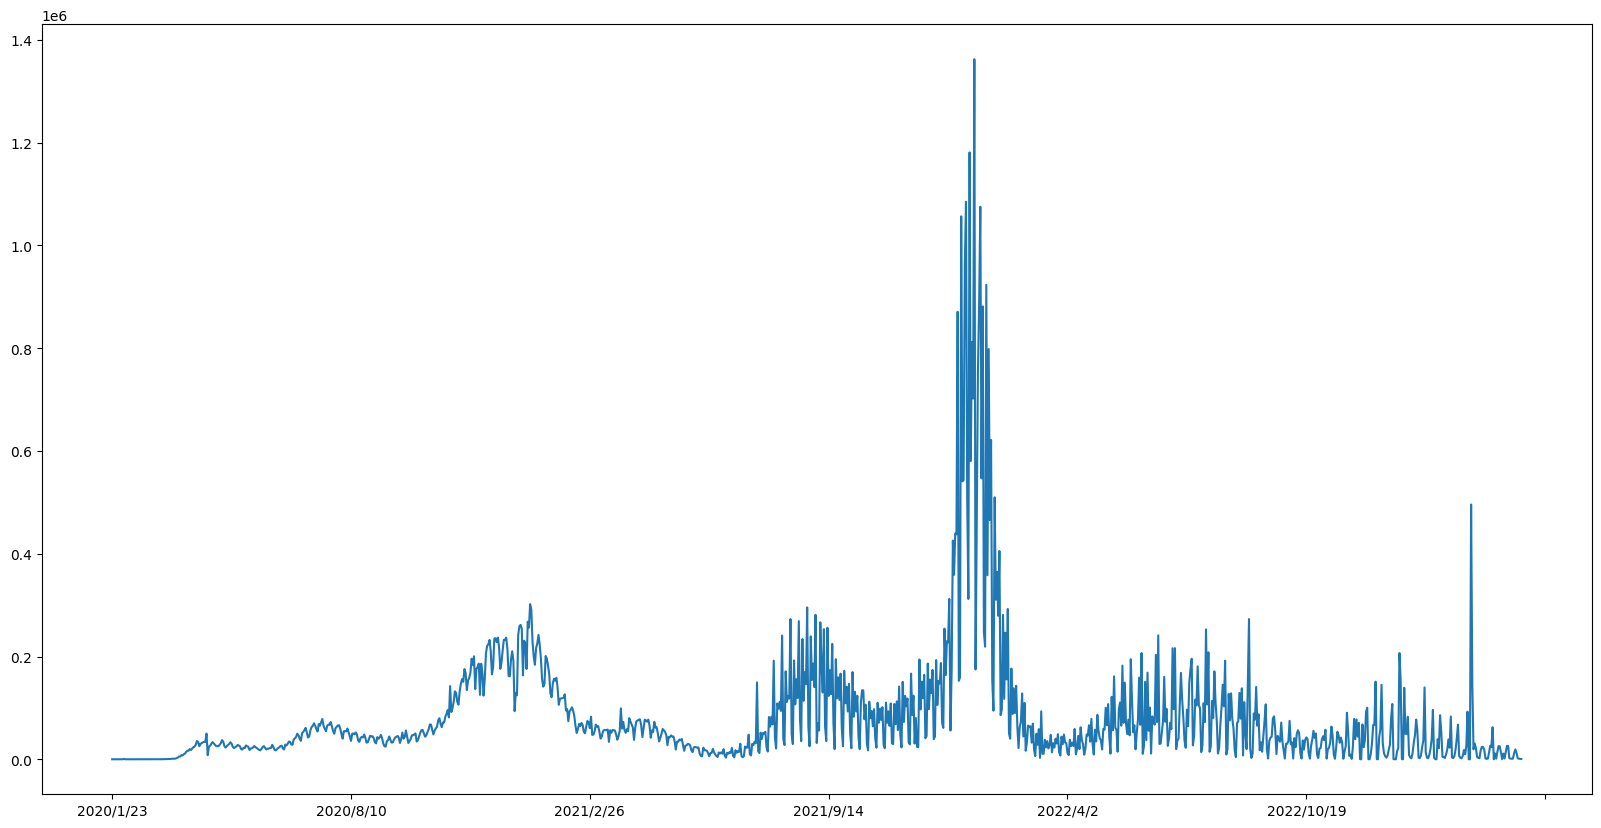

In [171]:
all_cases['daily'].plot(figsize=(20, 10))

<AxesSubplot: >

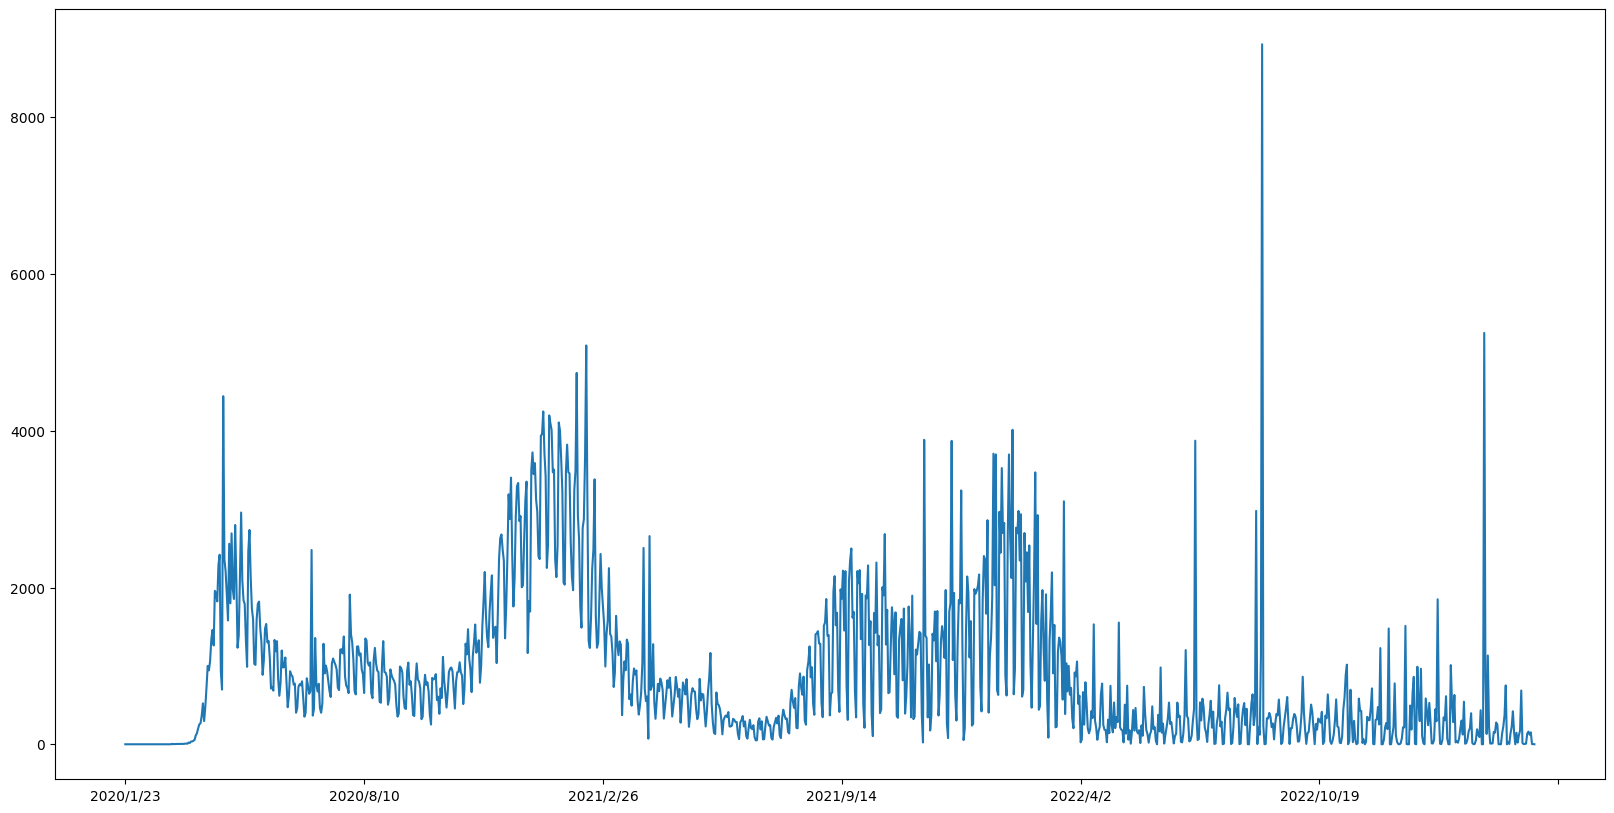

In [172]:
all_deaths['daily'].plot(figsize=(20, 10))

In [173]:
all_cases.head()

,sum,daily
2020/1/23,734.0,11.0
2020/1/24,741.0,7.0
2020/1/25,751.0,10.0
2020/1/26,759.0,8.0
2020/1/27,769.0,10.0


### May seperate the covid into 3 period according to 
https://www.thelancet.com/journals/laninf/article/PIIS1473-3099(22)00320-6/fulltext
1. before Jan 2021, the first COVID-19 vaccine wasn't delivered outside of a clinical trial setting
2. Jan 2021-Jan 2022, more than half population have received at least one dose of a COVID-19 vaccine
3. after Jan 2022

### Or
we use statistical methods and try to figure out different periods.

#### see the medians, might use median in one period I think

In [194]:
print(all_cases['daily'].idxmax())
all_cases.sort_values(by = 'daily',ascending = False).head(10)

2022/1/14


,sum,daily
2022/1/14,63514335.0,1362265.0
2022/1/10,60057935.0,1181015.0
2022/1/7,58055606.0,1085037.0
2022/1/19,66859028.0,1075290.0
2022/1/3,54926383.0,1056558.0
2022/1/6,56970569.0,959931.0
2022/1/24,69676589.0,923233.0
2022/1/18,65783738.0,887893.0
2022/1/21,68287066.0,881293.0
2021/12/31,53557811.0,870883.0


In [195]:
# the dataset is not normally distributed
w, pvalue = stats.shapiro(all_cases.daily)
print(w, pvalue)

0.539780855178833 0.0


In [ ]:
all_cases = all_cases[all_cases.index.values< '2021/01/01']

In [174]:
for row in all_cases['daily']:
    p1_df = all_cases[all_cases.index.values< '2021/01/01']
    p1_med = p1_df['daily'].median()
print(p1_med)
print('date around median1: ',p1_df.daily[p1_df.daily>=p1_med].idxmin())
print('date around median2: ',p1_df.daily[p1_df.daily<p1_med].idxmax())
print(p1_df[p1_df.index.values=='2020/9/12'])
print(p1_df[p1_df.index.values=='2020/6/23'])
p1_df

37996.0
date around median1:  2020/6/23
date around median2:  2020/9/12
                 sum    daily
2020/9/12  6417247.0  37732.0
                 sum    daily
2020/6/23  2371116.0  38260.0


,sum,daily
2020/1/23,734.0,11.0
2020/1/24,741.0,7.0
2020/1/25,751.0,10.0
2020/1/26,759.0,8.0
2020/1/27,769.0,10.0
...,...,...
2020/12/27,18867474.0,124648.0
2020/12/28,19109473.0,241999.0
2020/12/29,19368312.0,258839.0
2020/12/30,19629724.0,261412.0


In [175]:
for row in all_cases['daily']:
    p2_df = all_cases[all_cases.index.values <'2022/01/01']
    p2_df = p2_df[p2_df.index.values>= '2021/01/01']
    p2_med = p2_df['daily'].median()
print(p2_med)
print('date around median1: ',p2_df.daily[p2_df.daily>=p2_med].idxmin())
print('date around median2: ',p2_df.daily[p2_df.daily<p2_med].idxmax())
print(p2_df[p2_df.index.values=='2021/11/4'])
print(p2_df[p2_df.index.values=='2021/2/18'])
p2_df

64989.0
date around median1:  2021/11/4
date around median2:  2021/2/18
                  sum    daily
2021/11/4  45161773.0  64989.0
                  sum    daily
2021/2/18  27458587.0  64736.0


,sum,daily
2021/1/1,20047314.0,163324.0
2021/1/2,20278065.0,230751.0
2021/1/3,20503589.0,225524.0
2021/1/4,20679372.0,175783.0
2021/1/5,20947104.0,267732.0
...,...,...
2021/12/27,51450598.0,425580.0
2021/12/28,51809760.0,359162.0
2021/12/29,52249214.0,439454.0
2021/12/30,52686928.0,437714.0


In [176]:
for row in all_cases['daily']:
    p3_df = all_cases[all_cases.index.values>= '2022/01/01']
    p3_med = p3_df['daily'].median()
print(p3_med)

print('date around median1: ',p3_df.daily[p3_df.daily>=p3_med].idxmin())
print('date around median2: ',p3_df.daily[p3_df.daily<p3_med].idxmax())
print(p3_df[p3_df.index.values=='2022/10/9'])
print(p3_df[p3_df.index.values=='2022/4/29'])
p3_df

40966.0
date around median1:  2022/10/9
date around median2:  2022/4/29
                  sum    daily
2022/10/9  90747702.0  41032.0
                  sum    daily
2022/4/29  78790406.0  40900.0


,sum,daily
2022/1/1,53710526.0,152715.0
2022/1/2,53869825.0,159299.0
2022/1/3,54926383.0,1056558.0
2022/1/4,55467399.0,541016.0
2022/1/5,56010638.0,543239.0
...,...,...
2023/4/13,96919577.0,12617.0
2023/4/14,96921668.0,2091.0
2023/4/15,96922761.0,1093.0
2023/4/16,96923507.0,746.0


### ANOVA test, to see if there is significant difference between three groups - cases
I thought if there is some significant differences between groups, our methods would be more valid.
- seems fail to prove

In [177]:
# pick rows for periods to make the dataset balanced
sample_num = min(len(p1_df),len(p2_df),len(p3_df))

p1_df_sample = p1_df.sample(n=sample_num).reset_index()
p2_df_sample = p2_df.sample(n=sample_num).reset_index()
p3_df_sample = p3_df.sample(n=sample_num).reset_index()
p1_df_sample.drop(columns=['sum','index'],inplace = True)
p2_df_sample.drop(columns=['sum','index'],inplace = True)
p3_df_sample.drop(columns=['sum','index'],inplace = True)

# p1_df_sample = p1_df.reset_index().drop(columns=['sum','index'])
# p2_df_sample = p2_df.reset_index().drop(columns=['sum','index'])
# p3_df_sample = p3_df.reset_index().drop(columns=['sum','index'])


In [178]:
p1_df_sample.rename(columns={'daily':'p1d'},inplace = True)
p2_df_sample.rename(columns={'daily':'p2d'},inplace = True)
p3_df_sample.rename(columns={'daily':'p3d'},inplace = True)

In [179]:
p1_df_sample

,p1d
0,45343.0
1,14575.0
2,25.0
3,220610.0
4,232552.0
...,...
339,71443.0
340,62550.0
341,21962.0
342,39.0


In [180]:
df_anova = pd.concat([p1_df_sample,p2_df_sample,p3_df_sample],axis=1) 
df_anova

,p1d,p2d,p3d
0,45343.0,106888.0,0.0
1,14575.0,122758.0,139181.0
2,25.0,149616.0,74870.0
3,220610.0,6549.0,2570.0
4,232552.0,256353.0,41864.0
...,...,...,...
339,71443.0,19682.0,451057.0
340,62550.0,19068.0,41506.0
341,21962.0,5725.0,58625.0
342,39.0,30310.0,12617.0


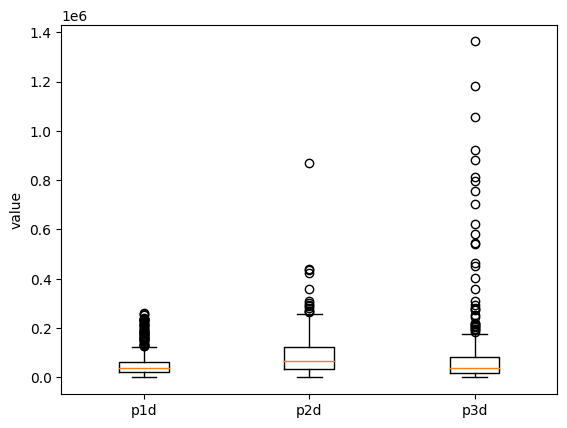

In [181]:
# reshape the d dataframe suitable for statsmodels package 
df_melt = pd.melt(df_anova.reset_index(), id_vars=['index'], value_vars=['p1d', 'p2d', 'p3d'])
# replace column names
df_melt.columns = ['index', 'periods', 'value']

# generate a boxplot to see the data distribution by treatments. Using boxplot, we can 
# easily detect the differences between different treatments
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1)
ax.boxplot([df_anova.p1d, df_anova.p2d, df_anova.p3d])
# ax.boxplot([p1_df_sample.p1d, p2_df_sample.p2d, p3_df_sample.p3d])
ax.set_xticklabels(["p1d", "p2d", "p3d"]) 
ax.set_ylabel("value") 
plt.show()

In [182]:
import scipy.stats as stats
# stats f_oneway functions takes the groups as input and returns ANOVA F and p value
fvalue, pvalue = stats.f_oneway(df_anova['p1d'], df_anova['p2d'], df_anova['p3d'])
# fvalue, pvalue = stats.f_oneway(p1_df_sample.p1d, p2_df_sample.p2d, p3_df_sample.p3d)
print(fvalue, pvalue)
# 9.619937034375106 7.255921847755048e-05

# get ANOVA table as R like output
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Ordinary Least Squares (OLS) model
model = ols('value ~ C(periods)', data=df_melt).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

9.619937034375106 7.255921847755048e-05


,sum_sq,df,F,PR(>F)
C(periods),2.568993e+11,2.0,9.619937,0.000073
Residual,1.373966e+13,1029.0,NaN,NaN


### It shows period 2 and 3 aren't significantly different in terms of cases, we may consider to just split the dataset into 2 groups

In [183]:
# ANOVA posthoc_tukey
from scipy.stats import tukey_hsd
res = tukey_hsd(df_anova.p1d, df_anova.p2d, df_anova.p3d)
print(res)

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1) -34638.953     0.000-55318.846-13959.061
 (0 - 2) -32162.233     0.001-52842.125-11482.340
 (1 - 0)  34638.953     0.000 13959.061 55318.846
 (1 - 2)   2476.721     0.957-18203.171 23156.613
 (2 - 0)  32162.233     0.001 11482.340 52842.125
 (2 - 1)  -2476.721     0.957-23156.613 18203.171



### Test ANOVA assumptions
- is not normally distributed
- Test Failed
- results is not convincing

In [186]:
import scipy.stats as stats
w, pvalue = stats.shapiro(model.resid)
print(w, pvalue)

0.574264645576477 1.8216880036222622e-44


In [187]:
import scipy.stats as stats
w, pvalue = stats.shapiro(p1_df_sample.p1d)
print('p1',w, pvalue)
w, pvalue = stats.shapiro(p2_df_sample.p2d)
print('p2',w, pvalue)
w, pvalue = stats.shapiro(p3_df_sample.p3d)
print('p3',w, pvalue)

p1 0.7775788903236389 2.6386267883262058e-21
p2 0.7690631151199341 1.1301556057655519e-21
p3 0.484164834022522 2.3165461529281936e-30


In [189]:
import scipy.stats as stats
w, pvalue = stats.bartlett(df_anova.p1d, df_anova.p2d, df_anova.p3d)
print(w, pvalue)

354.4962819835159 1.0522294183123046e-77


In [9]:
all_deaths['rate'] = all_deaths['daily'] / all_cases['daily']

In [10]:
all_cases['daily'].min()

0.0

In [11]:
all_deaths['rate'].max()

0.3982608695652174

<AxesSubplot: >

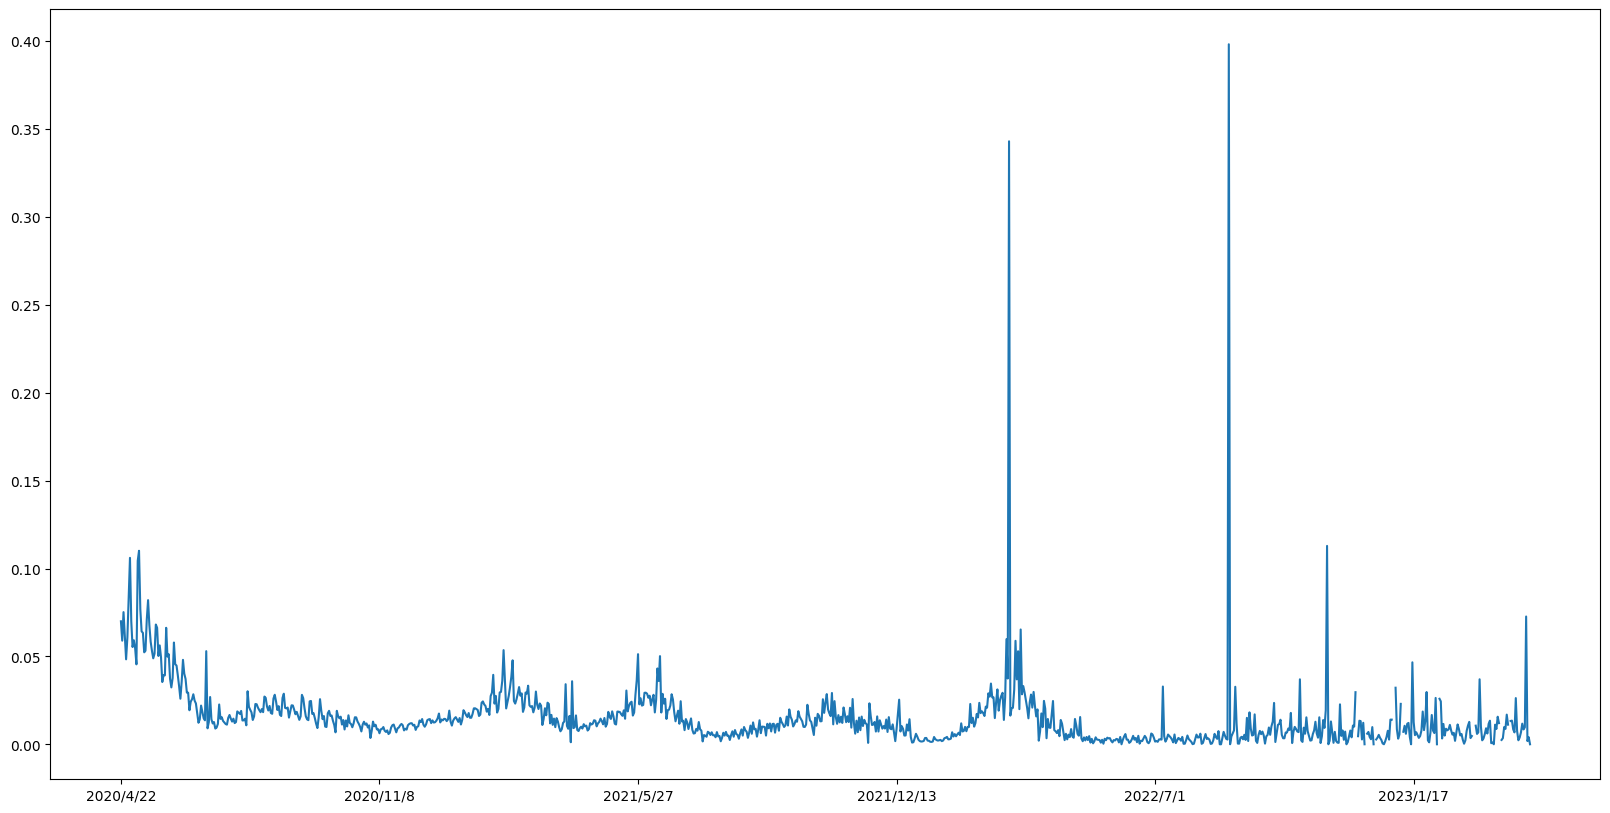

In [9]:
all_deaths['rate'][90:].plot(figsize=(20, 10))

In [2]:
df = pd.read_csv('df_main_final.csv')

In [3]:
df

,fips,Staffed_Beds,Total_Discharges,Patient_Days,Gross_Patient_Revenue,Hospitals,Local_Hospital,ADI_NATRANK,ADI_STATERNK,Value_education,...,pop_sex_female_age_65_and_above,pop_sex_male_age_0_to_18,pop_sex_male_age_18_to_65,pop_sex_male_age_65_and_above,pct_pop_sex_female_age_0_to_18,pct_pop_sex_female_age_18_to_65,pct_pop_sex_female_age_65_and_above,pct_pop_sex_male_age_0_to_18,pct_pop_sex_male_age_18_to_65,pct_pop_sex_male_age_65_and_above
0,1001,77.0,3049.0,15984.0,250284.0,1.0,1,66.977778,4.355556,21.714286,...,4807,6765,16604,3683,11.463182,2.703566e+05,8.639623,12.158738,29.842378,6.619459
1,1003,301.0,18080.0,78361.0,2481966.0,3.0,1,51.534483,2.655172,21.928571,...,24115,23873,61415,20601,10.591464,1.052924e+06,11.047282,10.936420,28.134720,9.437488
2,1005,47.0,1055.0,4571.0,76099.0,1.0,1,90.900000,7.950000,22.285714,...,2704,2589,8494,2073,10.521058,1.189912e+05,10.804763,10.345241,33.940702,8.283385
3,1007,156.0,229.0,1053.0,31288.0,1.0,1,83.411765,6.647059,21.571429,...,2059,2509,7896,1617,9.274157,1.064437e+05,9.202647,11.213908,35.290962,7.227138
4,1009,0.0,0.0,0.0,0.0,0.0,0,72.325581,4.906977,21.571429,...,5747,6873,17169,4635,11.252705,2.780570e+05,9.950653,11.900268,29.727297,8.025280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3119,56037,58.0,1279.0,4742.0,207720.0,2.0,1,54.088235,6.147059,22.360714,...,2767,5805,14010,2525,12.682229,2.082663e+05,6.382636,13.390386,32.316848,5.824414
3120,56039,121.0,1711.0,5932.0,273723.0,1.0,1,6.473684,1.000000,22.496429,...,1773,2394,8233,1708,7.698235,1.120697e+05,7.591198,10.250043,35.250043,7.312895
3121,56041,32.0,803.0,1627.0,105109.0,1.0,1,57.058824,7.117647,22.500000,...,1405,2989,5863,1463,14.081672,9.838124e+04,6.896043,14.670658,28.776872,7.180720
3122,56043,0.0,0.0,0.0,0.0,0.0,0,59.555556,7.777778,22.710714,...,902,966,2256,814,11.622337,3.799210e+04,11.370225,12.176982,28.438170,10.260935


<AxesSubplot: >

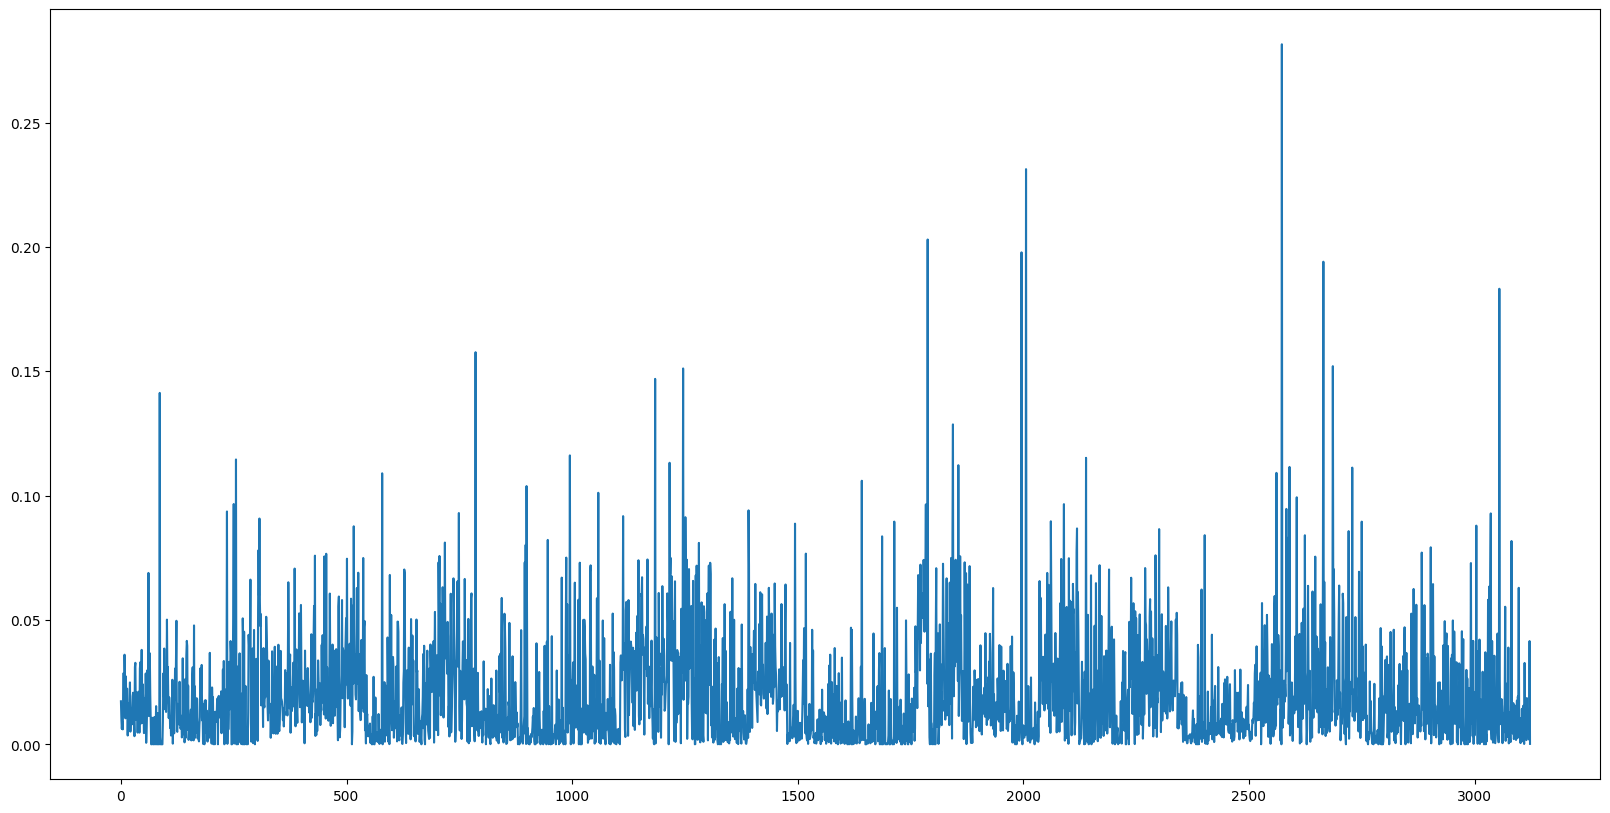

In [9]:
df['avg_death_rate'].plot(x="fips", y="case fatality rate",figsize=(20, 10))

Text(0.5, 0, 'Case Fatality Rate')

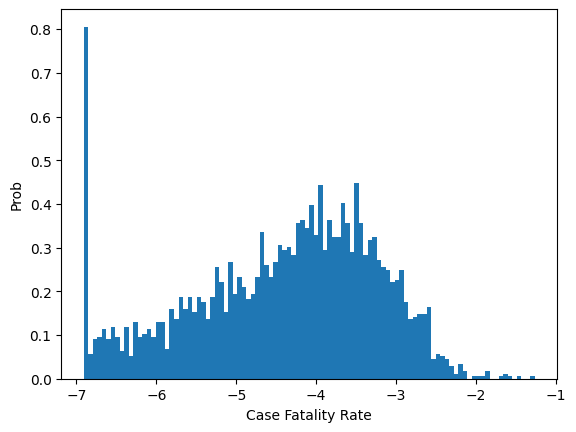

In [37]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

x = np.log(0.001+df['avg_death_rate'])

plt.hist(x, density=True, bins=100)  # density=False would make counts
plt.ylabel('Prob')
plt.xlabel('Case Fatality Rate')

In [21]:
np.log(df['avg_death_rate']+0.001)

0      -4.001387
1      -4.478852
2      -4.927965
3      -4.601062
4      -4.962502
          ...   
3119   -5.579386
3120   -5.331986
3121   -5.854670
3122   -3.158290
3123   -6.761261
Name: avg_death_rate, Length: 3124, dtype: float64

In [17]:
np.log(df['avg_death_rate'])

0      -4.057612
1      -4.571114
2      -5.076579
3      -4.705968
4      -5.116762
          ...   
3119   -5.887147
3120   -5.563727
3121   -6.283700
3122   -3.182102
3123   -8.754381
Name: avg_death_rate, Length: 3124, dtype: float64

In [33]:
import numpy as np

data = df['avg_death_rate']#np.log(df['avg_death_rate']+0.001) #
mean = np.mean(data)
std = np.std(data)
 
threshold = 3
outliers = []
for x in data:
    z_score = (x - mean) / std
    if abs(z_score) > threshold:
        outliers.append(x)
print("Mean: ",mean)
print("\nStandard deviation: ",std)
print("\nOutliers  : ", len(outliers))

Mean:  0.020040906392863784

Standard deviation:  0.022195561177377896

Outliers  :  43


In [30]:
import numpy as np
 
data = np.array(df['avg_death_rate'])
 
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1
threshold = 1.5 * iqr
outliers = np.where((data < q1 - threshold) | (data > q3 + threshold))
 
print("Outliers of array ",data,"is : \n", len(data[outliers]))

Outliers of array  [0.01729025 0.01034643 0.00624122 ... 0.00186648 0.04149833 0.00015777] is : 
 133


In [31]:
import numpy as np
from scipy import stats
 
data = np.array(df['avg_death_rate'])
 
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
outliers = np.where((data < lower_fence) | (data > upper_fence))
 
print("Outliers of array ",data,"is : \n", len(data[outliers]))


Outliers of array  [0.01729025 0.01034643 0.00624122 ... 0.00186648 0.04149833 0.00015777] is : 
 133


Text(0.5, 0, 'Case Fatality Rate')

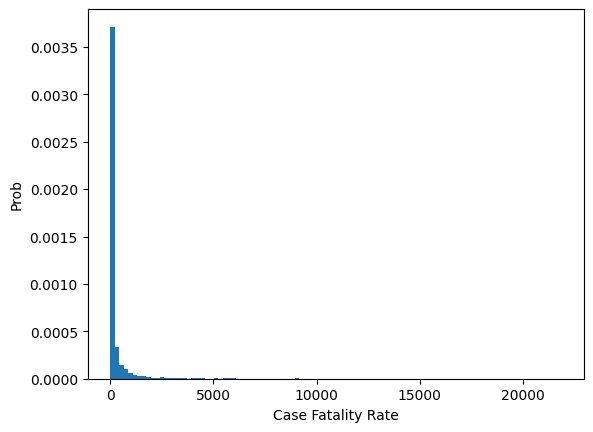

In [39]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

x = df['Staffed_Beds'] #np.log(0.001+df['avg_death_rate'])

plt.hist(x, density=True, bins=100)  # density=False would make counts
plt.ylabel('Prob')
plt.xlabel('Case Fatality Rate')